# OpenAI Compute Estimation via Microsoft's GPU Fleet Mix

This notebook:
1. Computes cumulative IT power of Microsoft's A100, H100, B200, and B300 fleet over time (median estimates)
2. Estimates OpenAI's chip counts by chip type, assuming OpenAI's compute mirrors Microsoft's fleet mix

**Caveats:**
- **No chip retirements assumed.** Cumulative counts never decrease. In practice, some A100s may have been retired by 2025, so A100 counts in later periods may be overstated.
- **Data begins in 2022.** Microsoft likely acquired A100s before 2022, so the A100 fleet (and its share of total compute) may be understated, particularly for 2022–2023 snapshots.


In [114]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

## 1. Load Data

Ben Cottier's cost-per-watt model contains IT power for common AI servers.

For example, here's the Colossus 1 (H100) model (see Calculations), which puts the H100 at 11.112 kW per server, including networking. 

https://docs.google.com/spreadsheets/d/1aXs4vx7AMrzUIR3YeBvJRAD_rmDiioY9zR95DZdDa_s/edit?gid=0#gid=0 

In addition, the GB200 is 150 kW of total IT power, found by multiplying the rated server power of the GB200 NVL72 with the IT power overhead factor of 1.14

https://docs.google.com/spreadsheets/d/1aXs4vx7AMrzUIR3YeBvJRAD_rmDiioY9zR95DZdDa_s/edit?gid=386717209#gid=386717209

For the GB300, this is 1.14 * 140 kW = 160 kW of IT power per NVL72.


In [115]:
# Load cumulative chip estimates
chips_df = pd.read_csv('nvidia_owners_cumulative_by_chip.csv')

# Load IT power per chip
power_df = pd.read_csv('IT power by chip.csv')
print('=== IT Power per Chip ===')
print(power_df.to_string(index=False))

# Load lab IT power
lab_df = pd.read_csv('lab IT power.csv')
lab_df['Date'] = pd.to_datetime(lab_df['Date'])
print('\n=== Lab IT Power ===')
print(lab_df.to_string(index=False))

=== IT Power per Chip ===
Chip type  Server power rating (W)  IT power per server (W)  Server size  IT power per GPU (W)                                                                                                                Notes
     A100                     6500                     7410            8                   926                             DGX A100 is officially 6500, bumping up 1.14 for IT power overhead (standard assumption)
     H100                    10200                    11112            8                  1389                                                                          including networking, based on SemiAnalysis
    GB200                   132000                   150000           72                  2083 https://docs.google.com/spreadsheets/d/1DuXY5E8qC-CqRrP7QgQdai5tUL-Qh4yxZITZVvBTB_o/edit?gid=400445942#gid=400445942
    GB300                   140000                   160000           72                  2222 https://docs.google.com/spreads

/var/folders/06/5htx0qw164j099bw2q7jk4gm0000gn/T/ipykernel_94961/1149840197.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  lab_df['Date'] = pd.to_datetime(lab_df['Date'])


## 2. Microsoft Fleet IT Power Over Time

We filter the chip ownership dataset to Microsoft's fleet of the four GPU types we care about, then compute each row's IT power draw using per-GPU wattages from the IT power CSV.

The chip names differ between the two datasets (e.g. the fleet data calls them "B200" while the power CSV calls them "GB200"), so we maintain a mapping between the two naming conventions.

In [116]:
# ---------------------------------------------------------------------------
# Filter to Microsoft's fleet for the four GPU types we're tracking
# ---------------------------------------------------------------------------
TARGET_CHIP_TYPES = ['A100', 'H100/H200', 'B200', 'B300']

msft_fleet = chips_df[
    (chips_df['Owner'] == 'Microsoft') &
    (chips_df['Chip type'].isin(TARGET_CHIP_TYPES))
].copy()

msft_fleet['End date'] = pd.to_datetime(msft_fleet['End date'])
msft_fleet = msft_fleet.sort_values('End date')

# ---------------------------------------------------------------------------
# Build watts-per-GPU lookup from the IT power CSV
# The CSV uses chip names like "GB200"; the fleet data uses "B200" — map between them
# ---------------------------------------------------------------------------
CSV_TO_FLEET_CHIP_NAME = {
    'A100':  'A100',
    'H100':  'H100/H200',
    'GB200': 'B200',
    'GB300': 'B300',
}

watts_per_gpu = {}
for _, row in power_df.iterrows():
    csv_name = row['Chip type']
    if csv_name in CSV_TO_FLEET_CHIP_NAME:
        watts_per_gpu[CSV_TO_FLEET_CHIP_NAME[csv_name]] = row['IT power per GPU (W)']

print('Watts per GPU (from IT power CSV):')
for chip, watts in watts_per_gpu.items():
    print(f'  {chip:12s} → {watts:,.0f} W')

# ---------------------------------------------------------------------------
# Compute derived columns: IT power in MW and H100-equivalents per chip row
# ---------------------------------------------------------------------------
msft_fleet['watts_per_gpu'] = msft_fleet['Chip type'].map(watts_per_gpu)
msft_fleet['IT_power_mw']   = msft_fleet['Number of Units'] * msft_fleet['watts_per_gpu'] / 1e6
msft_fleet['h100e']         = msft_fleet['Compute estimate in H100e (median)']
msft_fleet['h100e_per_gpu'] = msft_fleet['h100e'] / msft_fleet['Number of Units']

print(f'\nMicrosoft fleet: {len(msft_fleet)} rows')

# Show snapshot for Q4 of each year (2023, 2024, 2025)
year_end_dates = ['2023-12-31', '2024-12-31', '2025-12-31']
q4_snapshot = msft_fleet[msft_fleet['End date'].isin(pd.to_datetime(year_end_dates))].copy()

# Add % share of IT power within each date
q4_snapshot['IT power % share'] = q4_snapshot.groupby('End date')['IT_power_mw'].transform(lambda x: x / x.sum() * 100)

display_cols = ['End date', 'Chip type', 'Number of Units', 'h100e', 'watts_per_gpu', 'IT_power_mw', 'IT power % share']
q4_display = q4_snapshot[display_cols].copy()
q4_display['Number of Units'] = q4_display['Number of Units'].map('{:,.0f}'.format)
q4_display['h100e'] = q4_display['h100e'].map('{:,.0f}'.format)
q4_display['watts_per_gpu'] = q4_display['watts_per_gpu'].map('{:,.0f}'.format)
q4_display['IT_power_mw'] = q4_display['IT_power_mw'].map('{:,.1f}'.format)
q4_display['IT power % share'] = q4_display['IT power % share'].map('{:.1f}%'.format)
print(q4_display.to_string(index=False))

Watts per GPU (from IT power CSV):
  A100         → 926 W
  H100/H200    → 1,389 W
  B200         → 2,083 W
  B300         → 2,222 W

Microsoft fleet: 42 rows
  End date Chip type Number of Units     h100e watts_per_gpu IT_power_mw IT power % share
2023-12-31      A100         227,034    71,586           926       210.2            39.1%
2023-12-31 H100/H200         235,326   235,326         1,389       326.9            60.9%
2024-12-31      B200          55,416   140,011         2,083       115.4             7.2%
2024-12-31      A100         227,034    71,586           926       210.2            13.1%
2024-12-31 H100/H200         917,002   917,002         1,389     1,273.7            79.6%
2025-12-31      B300         323,881   818,295         2,222       719.7            21.1%
2025-12-31      A100         227,034    71,586           926       210.2             6.2%
2025-12-31 H100/H200       1,093,460 1,093,460         1,389     1,518.8            44.6%
2025-12-31      B200         45

### Pivot to time series by chip type

We reshape the fleet data into two time-series tables — one for IT power (MW) and one for H100-equivalents — where each row is a date and each column is a chip type. This makes it easy to see fleet composition over time and to plot stacked area charts.

In [117]:
# ---------------------------------------------------------------------------
# Pivot fleet data: rows = dates, columns = chip types
# ---------------------------------------------------------------------------

# IT power by chip type over time (MW)
power_by_chip_over_time = msft_fleet.pivot_table(
    index='End date', columns='Chip type', values='IT_power_mw', aggfunc='first'
).fillna(0).sort_index()

# H100-equivalents by chip type over time
h100e_by_chip_over_time = msft_fleet.pivot_table(
    index='End date', columns='Chip type', values='h100e', aggfunc='first'
).fillna(0).sort_index()

# Ensure every target chip has a column (some chips may not appear in early dates)
for chip in TARGET_CHIP_TYPES:
    if chip not in power_by_chip_over_time.columns:
        power_by_chip_over_time[chip] = 0.0
    if chip not in h100e_by_chip_over_time.columns:
        h100e_by_chip_over_time[chip] = 0.0

# Reorder columns and add totals
power_by_chip_over_time = power_by_chip_over_time[TARGET_CHIP_TYPES]
power_by_chip_over_time['Total'] = power_by_chip_over_time.sum(axis=1)

h100e_by_chip_over_time = h100e_by_chip_over_time[TARGET_CHIP_TYPES]
h100e_by_chip_over_time['Total'] = h100e_by_chip_over_time.sum(axis=1)

# Show combined view
combined_fleet_summary = pd.DataFrame({
    ('IT Power (MW)', chip): power_by_chip_over_time[chip]
    for chip in TARGET_CHIP_TYPES + ['Total']
} | {
    ('H100e', chip): h100e_by_chip_over_time[chip]
    for chip in TARGET_CHIP_TYPES + ['Total']
})
combined_fleet_summary.columns = pd.MultiIndex.from_tuples(combined_fleet_summary.columns)

# Filter to year-end rows only for display
year_end_summary = combined_fleet_summary[combined_fleet_summary.index.month == 12]

print('Microsoft cumulative fleet (year-end snapshots): IT Power (MW) and H100-equivalents')
year_end_summary.round(0).astype(int).map(lambda x: f'{x:,}' if x >= 10000 else str(x))

Microsoft cumulative fleet (year-end snapshots): IT Power (MW) and H100-equivalents


IT Power (MW)                             H100e             \
                    A100 H100/H200 B200 B300 Total    A100  H100/H200   
End date                                                                
2022-12-31           161        14    0    0   175  54,891     10,027   
2023-12-31           210       327    0    0   537  71,586    235,326   
2024-12-31           210      1274  115    0  1599  71,586    917,002   
2025-12-31           210      1519  957  720  3406  71,586  1,093,460   

                                           
                 B200     B300      Total  
End date                                   
2022-12-31          0        0     64,918  
2023-12-31          0        0    306,912  
2024-12-31    140,011        0  1,128,599  
2025-12-31  1,160,893  818,295  3,144,234

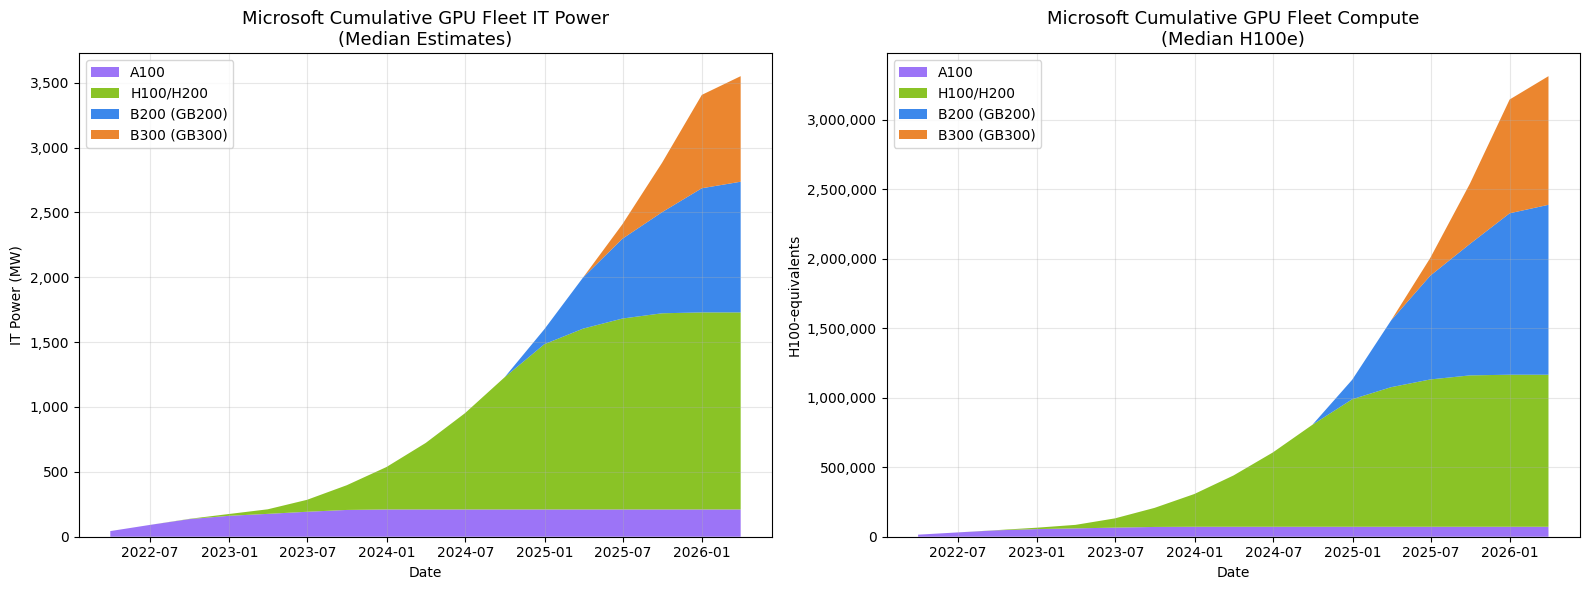

In [118]:
# ---------------------------------------------------------------------------
# Stacked area charts: IT power and H100e over time
# ---------------------------------------------------------------------------
CHIP_COLORS = {'A100': '#8b5cf6', 'H100/H200': '#76b900', 'B200': '#1a73e8', 'B300': '#e8710a'}
CHIP_DISPLAY_NAMES = {'A100': 'A100', 'H100/H200': 'H100/H200', 'B200': 'B200 (GB200)', 'B300': 'B300 (GB300)'}

fig, (ax_power, ax_h100e) = plt.subplots(1, 2, figsize=(16, 6))

# Left: IT Power
ax_power.stackplot(
    power_by_chip_over_time.index,
    [power_by_chip_over_time[c] for c in TARGET_CHIP_TYPES],
    labels=[CHIP_DISPLAY_NAMES[c] for c in TARGET_CHIP_TYPES],
    colors=[CHIP_COLORS[c] for c in TARGET_CHIP_TYPES],
    alpha=0.85
)
ax_power.set_title('Microsoft Cumulative GPU Fleet IT Power\n(Median Estimates)', fontsize=13)
ax_power.set_ylabel('IT Power (MW)')
ax_power.set_xlabel('Date')
ax_power.legend(loc='upper left')
ax_power.grid(True, alpha=0.3)
ax_power.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Right: H100e
ax_h100e.stackplot(
    h100e_by_chip_over_time.index,
    [h100e_by_chip_over_time[c] for c in TARGET_CHIP_TYPES],
    labels=[CHIP_DISPLAY_NAMES[c] for c in TARGET_CHIP_TYPES],
    colors=[CHIP_COLORS[c] for c in TARGET_CHIP_TYPES],
    alpha=0.85
)
ax_h100e.set_title('Microsoft Cumulative GPU Fleet Compute\n(Median H100e)', fontsize=13)
ax_h100e.set_ylabel('H100-equivalents')
ax_h100e.set_xlabel('Date')
ax_h100e.legend(loc='upper left')
ax_h100e.grid(True, alpha=0.3)
ax_h100e.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

## 3. Estimate OpenAI Chip Counts from Microsoft Fleet Mix


### How the incremental model works

We want to estimate how many GPUs of each type OpenAI has, given only its total IT power at a few year-end dates (end of 2023, 2024, 2025). The key assumption is that OpenAI's chip mix mirrors Microsoft's fleet.

**Period-by-period logic:**

1. **End of 2023 (200 MW):** This is the first period, so we allocate the full 200 MW using Microsoft's *cumulative* fleet mix through end of 2023. Because this includes all of Microsoft's 2022–2023 purchases, the A100 share is higher than it would be if we only looked at 2023 additions — A100s dominated Microsoft's early fleet before H100 shipments ramped up.

2. **End of 2024 (600 MW):** Only the *new* 400 MW gets allocated. The allocation uses the mix of chips Microsoft *added* between end-2023 and end-2024 (mostly H100s), not the cumulative mix. The 200 MW worth of chips from the previous period carry forward unchanged.

3. **End of 2025 (1,900 MW):** Same logic — the new 1,300 MW is allocated using Microsoft's end-2024 → end-2025 incremental mix (where B200/B300 start appearing). Earlier chips carry forward.

This prevents retroactively converting A100s into B200s when the fleet mix shifts toward newer chips — once chips are "deployed" in a period, they stay.

**Deployment delay (for sensitivity analysis):** When looking up Microsoft's fleet snapshot for a given OpenAI date, we can optionally subtract a delay (e.g. 3 or 6 months) to account for the lag between Nvidia revenue recognition and actual deployment in data centers.


In [119]:
from dateutil.relativedelta import relativedelta

def estimate_lab_chip_counts(
    lab_power_df,
    msft_power_by_chip,
    msft_fleet_df,
    chip_types,
    watts_per_gpu_map,
    delay_months=0,
    verbose=False,
):
    """Estimate OpenAI's GPU fleet by chip type using Microsoft's fleet mix.
    
    Args:
        lab_power_df:        DataFrame with 'Date' and 'Total IT power (MW)' columns
        msft_power_by_chip:  Pivot table of Microsoft's IT power by chip type over time
        msft_fleet_df:       Raw Microsoft fleet DataFrame (for H100e-per-GPU lookups)
        chip_types:          List of chip type names to allocate across
        watts_per_gpu_map:   Dict mapping chip type → watts per GPU
        delay_months:        How many months to shift the Microsoft snapshot back
        verbose:             If True, print allocation details for each period
    
    Returns:
        DataFrame with one row per (lab_date, chip_type)
    """
    lab_dates = sorted(lab_power_df['Date'].unique())
    
    # Running state: cumulative chip counts and H100e carried forward across periods
    cumulative_chips_by_type = {chip: 0.0 for chip in chip_types}
    cumulative_h100e_by_type = {chip: 0.0 for chip in chip_types}
    previous_lab_power_mw = 0.0
    previous_msft_snapshot_date = None
    
    rows = []
    
    for lab_date in lab_dates:
        # How much total IT power does OpenAI have at this date?
        current_lab_power_mw = lab_power_df.loc[
            lab_power_df['Date'] == lab_date, 'Total IT power (MW)'
        ].values[0]
        new_power_to_allocate_mw = current_lab_power_mw - previous_lab_power_mw
        
        # Find the closest Microsoft fleet snapshot on or before (lab_date - delay)
        lookup_date = lab_date - relativedelta(months=delay_months)
        available_msft_dates = msft_power_by_chip.index[msft_power_by_chip.index <= lookup_date]
        if len(available_msft_dates) == 0:
            continue
        msft_snapshot_date = available_msft_dates[-1]
        
        # ---------------------------------------------------------------
        # Determine the chip-type mix to use for allocating new power
        # ---------------------------------------------------------------
        if previous_msft_snapshot_date is None:
            # First period: use Microsoft's full cumulative fleet mix
            msft_snapshot = msft_power_by_chip.loc[msft_snapshot_date]
            total_msft_power = msft_snapshot['Total']
            if total_msft_power == 0:
                continue
            mix_fractions = {
                chip: msft_snapshot[chip] / total_msft_power
                for chip in chip_types
            }
            if verbose:
                print(f'\n{lab_date.strftime("%Y-%m-%d")}: {current_lab_power_mw:.0f} MW total, '
                      f'{new_power_to_allocate_mw:.0f} MW new (first period, using cumulative MSFT mix)')
        else:
            # Incremental: use the mix of chips Microsoft ADDED since last snapshot
            current_msft = msft_power_by_chip.loc[msft_snapshot_date]
            previous_msft = msft_power_by_chip.loc[previous_msft_snapshot_date]
            
            msft_new_power_by_chip = {
                chip: max(0, current_msft[chip] - previous_msft[chip])
                for chip in chip_types
            }
            total_new_msft_power = sum(msft_new_power_by_chip.values())
            
            if total_new_msft_power == 0:
                # Microsoft added no new chips — fall back to cumulative mix
                total_msft_power = current_msft['Total']
                mix_fractions = {chip: current_msft[chip] / total_msft_power for chip in chip_types}
                if verbose:
                    print(f'\n{lab_date.strftime("%Y-%m-%d")}: {current_lab_power_mw:.0f} MW total, '
                          f'{new_power_to_allocate_mw:.0f} MW new (no MSFT additions, using cumulative mix)')
            else:
                mix_fractions = {
                    chip: msft_new_power_by_chip[chip] / total_new_msft_power
                    for chip in chip_types
                }
                if verbose:
                    print(f'\n{lab_date.strftime("%Y-%m-%d")}: {current_lab_power_mw:.0f} MW total, '
                          f'{new_power_to_allocate_mw:.0f} MW new (using MSFT incremental mix)')
        
        if verbose:
            print(f'  MSFT snapshot: {msft_snapshot_date.strftime("%Y-%m-%d")}')
            print(f'  Mix: ' + ', '.join(f'{chip}={mix_fractions[chip]:.1%}' for chip in chip_types if mix_fractions[chip] > 0))
        
        # ---------------------------------------------------------------
        # Allocate new power across chip types and update running totals
        # ---------------------------------------------------------------
        for chip in chip_types:
            power_for_this_chip_mw = new_power_to_allocate_mw * mix_fractions[chip]
            watts_per_gpu_mw = watts_per_gpu_map[chip] / 1e6
            new_gpus = power_for_this_chip_mw / watts_per_gpu_mw
            
            # Look up H100e-per-GPU from Microsoft's fleet at this snapshot
            matching_msft_rows = msft_fleet_df[
                (msft_fleet_df['End date'] == msft_snapshot_date) &
                (msft_fleet_df['Chip type'] == chip)
            ]
            h100e_per_gpu = matching_msft_rows.iloc[0]['h100e_per_gpu'] if len(matching_msft_rows) > 0 else 0
            
            cumulative_chips_by_type[chip] += new_gpus
            cumulative_h100e_by_type[chip] += new_gpus * h100e_per_gpu
            
            rows.append({
                'Lab Date': lab_date,
                'Lab IT Power (MW)': current_lab_power_mw,
                'New Power (MW)': new_power_to_allocate_mw,
                'MSFT Snapshot': msft_snapshot_date,
                'Chip Type': chip,
                'Incremental Mix %': mix_fractions[chip] * 100,
                'New Chips Added': int(round(new_gpus)),
                'Cumulative Chip Count': int(round(cumulative_chips_by_type[chip])),
                'Chip IT Power (MW)': round(cumulative_chips_by_type[chip] * watts_per_gpu_mw, 1),
                'H100e/unit': round(h100e_per_gpu, 2),
                'Cumulative H100e': int(round(cumulative_h100e_by_type[chip])),
            })
        
        previous_lab_power_mw = current_lab_power_mw
        previous_msft_snapshot_date = msft_snapshot_date
    
    return pd.DataFrame(rows)

In [120]:
# ---------------------------------------------------------------------------
# Run the baseline model (no deployment delay) with verbose output
# ---------------------------------------------------------------------------
lab_results = estimate_lab_chip_counts(
    lab_power_df=lab_df,
    msft_power_by_chip=power_by_chip_over_time,
    msft_fleet_df=msft_fleet,
    chip_types=TARGET_CHIP_TYPES,
    watts_per_gpu_map=watts_per_gpu,
    delay_months=0,
    verbose=True,
)

print('\n' + '='*80)
print('Full results table:')
lab_results


2023-12-31: 200 MW total, 200 MW new (first period, using cumulative MSFT mix)
  MSFT snapshot: 2023-12-31
  Mix: A100=39.1%, H100/H200=60.9%

2024-12-31: 600 MW total, 400 MW new (using MSFT incremental mix)
  MSFT snapshot: 2024-12-31
  Mix: H100/H200=89.1%, B200=10.9%

2025-12-31: 1900 MW total, 1300 MW new (using MSFT incremental mix)
  MSFT snapshot: 2025-12-31
  Mix: H100/H200=13.6%, B200=46.6%, B300=39.8%

Full results table:


,Lab Date,Lab IT Power (MW),New Power (MW),MSFT Snapshot,Chip Type,Incremental Mix %,New Chips Added,Cumulative Chip Count,Chip IT Power (MW),H100e/unit,Cumulative H100e
0,2023-12-31,200,200.0,2023-12-31,A100,39.142241,84540,84540,78.3,0.32,26656
1,2023-12-31,200,200.0,2023-12-31,H100/H200,60.857759,87628,87628,121.7,1.00,87628
2,2023-12-31,200,200.0,2023-12-31,B200,0.000000,0,0,0.0,0.00,0
3,2023-12-31,200,200.0,2023-12-31,B300,0.000000,0,0,0.0,0.00,0
4,2024-12-31,600,400.0,2024-12-31,A100,0.000000,0,84540,78.3,0.32,26656
5,2024-12-31,600,400.0,2024-12-31,H100/H200,89.133601,256684,344312,478.2,1.00,344312
6,2024-12-31,600,400.0,2024-12-31,B200,10.866399,20867,20867,43.5,2.53,52721
7,2024-12-31,600,400.0,2024-12-31,B300,0.000000,0,0,0.0,0.00,0
8,2025-12-31,1900,1300.0,2025-12-31,A100,0.000000,0,84540,78.3,0.32,26656
9,2025-12-31,1900,1300.0,2025-12-31,H100/H200,13.568198,126988,471301,654.6,1.00,471301


In [121]:
# ---------------------------------------------------------------------------
# Summary pivot: totals by date
# ---------------------------------------------------------------------------
summary = lab_results.pivot_table(
    index='Lab Date',
    columns='Chip Type',
    values=['Cumulative Chip Count', 'Cumulative H100e', 'Chip IT Power (MW)'],
    aggfunc='first'
)

for metric in ['Chip IT Power (MW)', 'Cumulative Chip Count', 'Cumulative H100e']:
    summary[(metric, 'Total')] = summary[metric].sum(axis=1)

print('Summary by date (incremental model, no delay):')
summary.round(1)

Summary by date (incremental model, no delay):


Chip IT Power (MW)                         Cumulative Chip Count  \
Chip Type                A100   B200   B300 H100/H200                  A100   
Lab Date                                                                      
2023-12-31               78.3    0.0    0.0     121.7                 84540   
2024-12-31               78.3   43.5    0.0     478.2                 84540   
2025-12-31               78.3  649.2  517.9     654.6                 84540   

                                     Cumulative H100e                  \
Chip Type     B200    B300 H100/H200             A100    B200    B300   
Lab Date                                                                
2023-12-31       0       0     87628            26656       0       0   
2024-12-31   20867       0    344312            26656   52721       0   
2025-12-31  311653  233081    471301            26656  787400  588887   

                     Chip IT Power (MW) Cumulative Chip Count Cumulative H100e  
Chip Type  H100/H200              Total                 Total            Total  
Lab Date                                                                        
2023-12-31     87628              200.0                172168           114284  
2024-12-31    344312              600.0                449719           423689  
2025-12-31    471301             1900.0               1100575          1874244

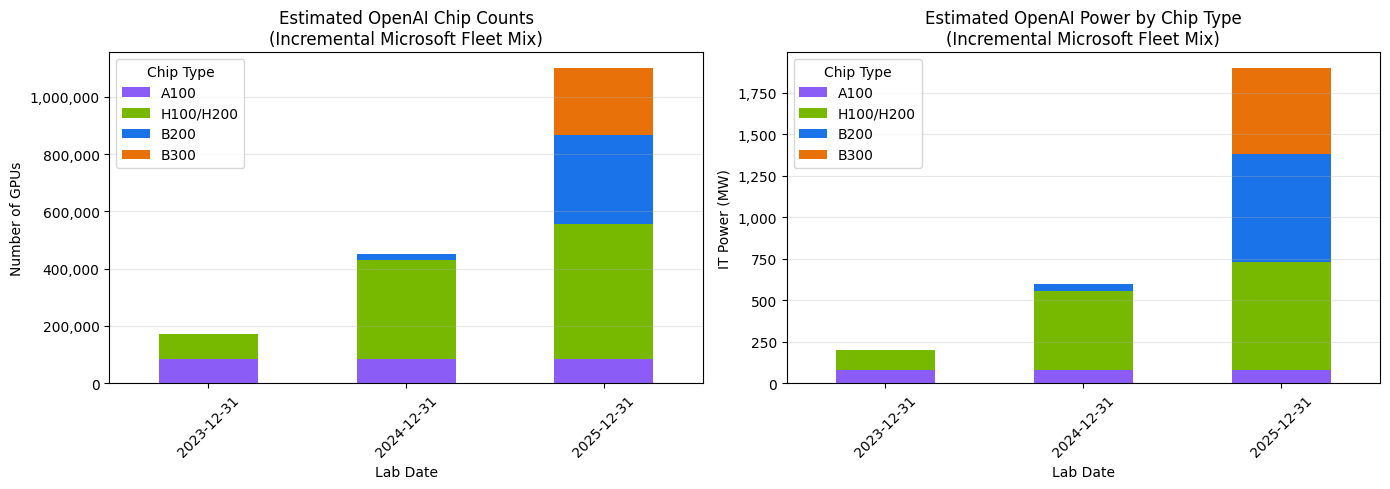

In [122]:
fig, (ax_counts, ax_power) = plt.subplots(1, 2, figsize=(14, 5))

# Left: chip counts
lab_chip_counts = lab_results.pivot_table(
    index='Lab Date', columns='Chip Type', values='Cumulative Chip Count', aggfunc='first'
).fillna(0)[TARGET_CHIP_TYPES]

lab_chip_counts.plot(kind='bar', stacked=True, ax=ax_counts,
                     color=[CHIP_COLORS[c] for c in TARGET_CHIP_TYPES])
ax_counts.set_title('Estimated OpenAI Chip Counts\n(Incremental Microsoft Fleet Mix)', fontsize=12)
ax_counts.set_ylabel('Number of GPUs')
ax_counts.set_xticklabels([d.strftime('%Y-%m-%d') for d in lab_chip_counts.index], rotation=45)
ax_counts.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax_counts.legend(title='Chip Type')
ax_counts.grid(True, alpha=0.3, axis='y')

# Right: power allocation
lab_chip_power = lab_results.pivot_table(
    index='Lab Date', columns='Chip Type', values='Chip IT Power (MW)', aggfunc='first'
).fillna(0)[TARGET_CHIP_TYPES]

lab_chip_power.plot(kind='bar', stacked=True, ax=ax_power,
                    color=[CHIP_COLORS[c] for c in TARGET_CHIP_TYPES])
ax_power.set_title('Estimated OpenAI Power by Chip Type\n(Incremental Microsoft Fleet Mix)', fontsize=12)
ax_power.set_ylabel('IT Power (MW)')
ax_power.set_xticklabels([d.strftime('%Y-%m-%d') for d in lab_chip_power.index], rotation=45)
ax_power.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax_power.legend(title='Chip Type')
ax_power.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 4. Sensitivity Analysis: Acquisition-to-Deployment Delay

Nvidia revenue recognition reflects when chips are *sold*, not when they're operational in data centers. A deployment delay means OpenAI's incremental additions at date X correspond to Microsoft's purchase mix from X minus the delay. We test 0 (baseline), 1-quarter (3 months), and 2-quarter (6 months) delays.


In [123]:
# ---------------------------------------------------------------------------
# Run the model for each delay scenario
# ---------------------------------------------------------------------------
DELAY_SCENARIOS = {
    'No delay (baseline)':        0,
    '1-quarter delay (3 months)': 3,
    '2-quarter delay (6 months)': 6,
}

delay_scenario_results = {}
for scenario_name, months in DELAY_SCENARIOS.items():
    delay_scenario_results[scenario_name] = estimate_lab_chip_counts(
        lab_power_df=lab_df,
        msft_power_by_chip=power_by_chip_over_time,
        msft_fleet_df=msft_fleet,
        chip_types=TARGET_CHIP_TYPES,
        watts_per_gpu_map=watts_per_gpu,
        delay_months=months,
    )

# ---------------------------------------------------------------------------
# Build a comparison table: one row per (scenario, lab_date)
# ---------------------------------------------------------------------------
comparison_rows = []
for scenario_name, scenario_df in delay_scenario_results.items():
    for lab_date in scenario_df['Lab Date'].unique():
        date_slice = scenario_df[scenario_df['Lab Date'] == lab_date]
        comparison_rows.append({
            'Delay Scenario': scenario_name,
            'Lab Date': lab_date,
            'MSFT Snapshot Used': date_slice['MSFT Snapshot'].iloc[0],
            'Total Chips': date_slice['Cumulative Chip Count'].sum(),
            'Total H100e': date_slice['Cumulative H100e'].sum(),
            # Per-chip breakdowns
            **{f'{chip} chips': date_slice.loc[date_slice['Chip Type'] == chip, 'Cumulative Chip Count'].sum()
               for chip in TARGET_CHIP_TYPES},
            **{f'{chip} H100e': date_slice.loc[date_slice['Chip Type'] == chip, 'Cumulative H100e'].sum()
               for chip in TARGET_CHIP_TYPES},
        })

delay_comparison = pd.DataFrame(comparison_rows)
print('Deployment delay sensitivity (incremental model):')
delay_comparison

Deployment delay sensitivity (incremental model):


,Delay Scenario,Lab Date,MSFT Snapshot Used,Total Chips,Total H100e,A100 chips,H100/H200 chips,B200 chips,B300 chips,A100 H100e,H100/H200 H100e,B200 H100e,B300 H100e
0,No delay (baseline),2023-12-31,2023-12-31,172168,114284,84540,87628,0,0,26656,87628,0,0
1,No delay (baseline),2024-12-31,2024-12-31,449719,423689,84540,344312,20867,0,26656,344312,52721,0
2,No delay (baseline),2025-12-31,2025-12-31,1100575,1874244,84540,471301,311653,233081,26656,471301,787400,588887
3,1-quarter delay (3 months),2023-12-31,2023-09-30,181429,104524,112321,69108,0,0,35416,69108,0,0
4,1-quarter delay (3 months),2024-12-31,2024-09-30,470071,391800,114316,355755,0,0,36045,355755,0,0
5,1-quarter delay (3 months),2025-12-31,2025-09-30,1178108,1754848,114316,634707,294176,134909,36045,634707,743245,340851
6,2-quarter delay (6 months),2023-12-31,2023-06-30,192673,92671,146054,46619,0,0,46052,46619,0,0
7,2-quarter delay (6 months),2024-12-31,2024-06-30,484497,376594,157594,326903,0,0,49691,326903,0,0
8,2-quarter delay (6 months),2025-12-31,2025-06-30,1261756,1624851,157594,795621,263514,45027,49691,795621,665776,113763


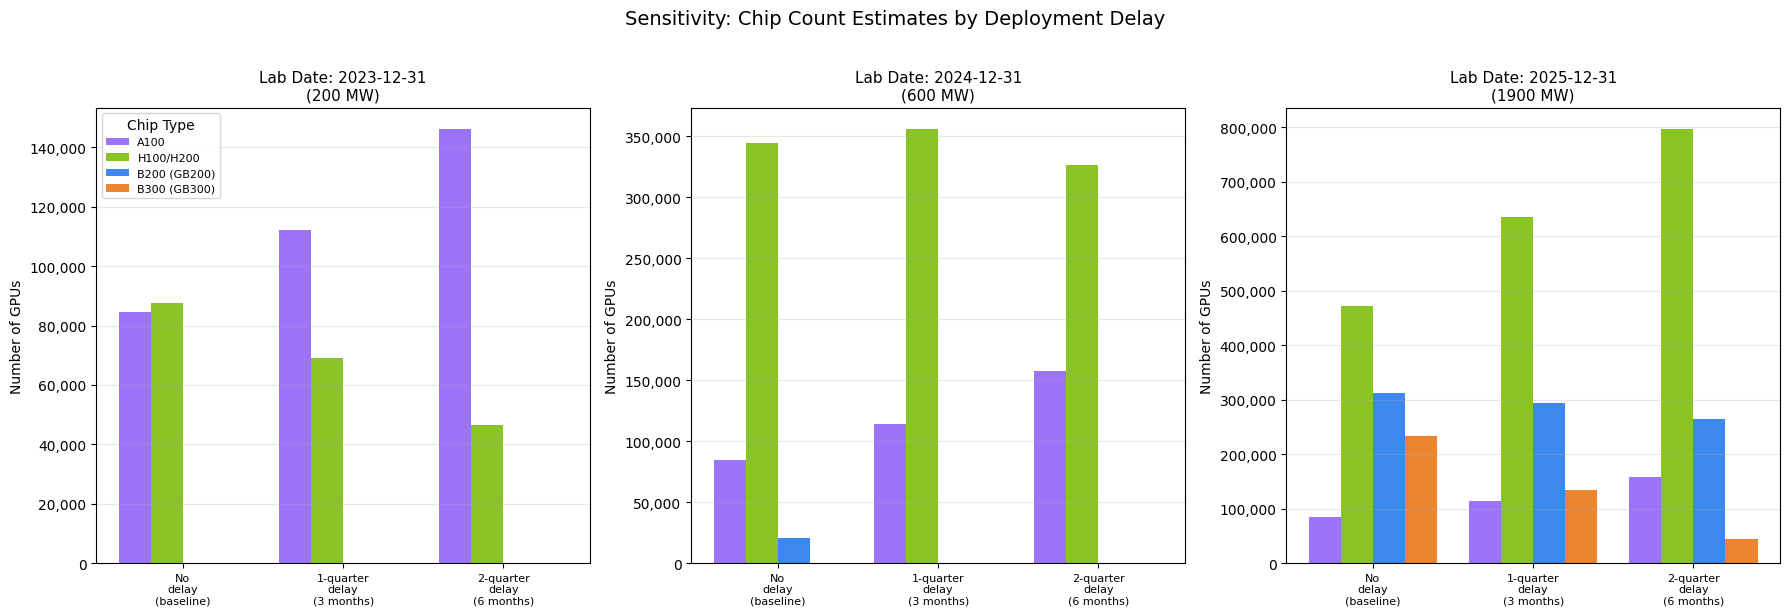

In [124]:
# ---------------------------------------------------------------------------
# Grouped bar charts: chip counts by delay scenario, one subplot per lab date
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

scenario_names = list(DELAY_SCENARIOS.keys())
lab_dates = sorted(delay_comparison['Lab Date'].unique())
x_positions = np.arange(len(scenario_names))
num_chip_types = len(TARGET_CHIP_TYPES)
bar_width = 0.8 / num_chip_types

for date_idx, lab_date in enumerate(lab_dates):
    ax = axes[date_idx]
    date_rows = delay_comparison[delay_comparison['Lab Date'] == lab_date]
    
    for chip_idx, chip in enumerate(TARGET_CHIP_TYPES):
        chip_counts = [
            date_rows.loc[date_rows['Delay Scenario'] == s, f'{chip} chips'].values[0]
            if len(date_rows[date_rows['Delay Scenario'] == s]) > 0 else 0
            for s in scenario_names
        ]
        ax.bar(x_positions + chip_idx * bar_width, chip_counts, bar_width,
               label=CHIP_DISPLAY_NAMES[chip], color=CHIP_COLORS[chip], alpha=0.85)
    
    lab_power_mw = int(lab_df[lab_df['Date'] == lab_date]['Total IT power (MW)'].values[0])
    ax.set_title(f'Lab Date: {lab_date.strftime("%Y-%m-%d")}\n({lab_power_mw} MW)', fontsize=11)
    ax.set_xticks(x_positions + bar_width * (num_chip_types - 1) / 2)
    ax.set_xticklabels([s.replace(' delay ', '\ndelay\n').replace(' (baseline)', '\n(baseline)')
                        for s in scenario_names], fontsize=8)
    ax.set_ylabel('Number of GPUs')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.grid(True, alpha=0.3, axis='y')
    if date_idx == 0:
        ax.legend(title='Chip Type', fontsize=8)

fig.suptitle('Sensitivity: Chip Count Estimates by Deployment Delay', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

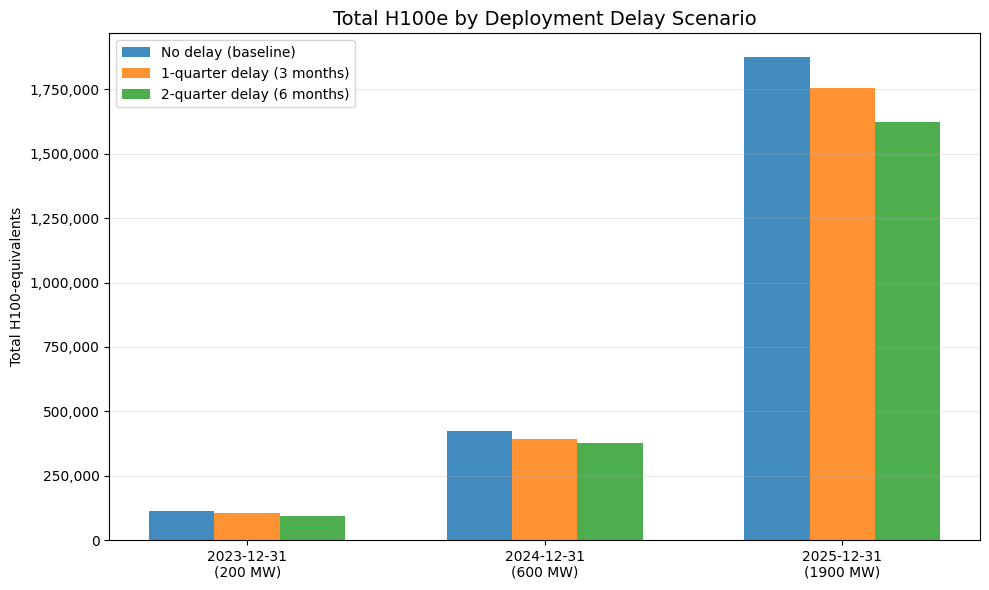


H100e % change vs no-delay baseline:

  2023-12-31  (baseline: 114,284 H100e)
    1-quarter delay (3 months)         :      104,524  (-8.5%)
    2-quarter delay (6 months)         :       92,671  (-18.9%)

  2024-12-31  (baseline: 423,689 H100e)
    1-quarter delay (3 months)         :      391,800  (-7.5%)
    2-quarter delay (6 months)         :      376,594  (-11.1%)

  2025-12-31  (baseline: 1,874,244 H100e)
    1-quarter delay (3 months)         :    1,754,848  (-6.4%)
    2-quarter delay (6 months)         :    1,624,851  (-13.3%)


In [125]:
# ---------------------------------------------------------------------------
# H100e totals by delay scenario
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.22
date_positions = np.arange(len(lab_dates))

for i, (scenario_name, months) in enumerate(DELAY_SCENARIOS.items()):
    h100e_totals = []
    for lab_date in lab_dates:
        match = delay_comparison[
            (delay_comparison['Lab Date'] == lab_date) &
            (delay_comparison['Delay Scenario'] == scenario_name)
        ]
        h100e_totals.append(match['Total H100e'].values[0] if len(match) > 0 else 0)
    ax.bar(date_positions + i * bar_width, h100e_totals, bar_width, label=scenario_name, alpha=0.85)

ax.set_title('Total H100e by Deployment Delay Scenario', fontsize=14)
ax.set_ylabel('Total H100-equivalents')
ax.set_xticks(date_positions + bar_width)
ax.set_xticklabels([
    f'{d.strftime("%Y-%m-%d")}\n({int(lab_df[lab_df["Date"]==d]["Total IT power (MW)"].values[0])} MW)'
    for d in lab_dates
])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# Print percentage change vs baseline
# ---------------------------------------------------------------------------
print('\nH100e % change vs no-delay baseline:')
for lab_date in lab_dates:
    baseline_h100e = delay_comparison[
        (delay_comparison['Lab Date'] == lab_date) &
        (delay_comparison['Delay Scenario'] == 'No delay (baseline)')
    ]['Total H100e'].values[0]
    print(f'\n  {lab_date.strftime("%Y-%m-%d")}  (baseline: {baseline_h100e:,.0f} H100e)')
    for scenario_name in list(DELAY_SCENARIOS.keys())[1:]:
        scenario_h100e = delay_comparison[
            (delay_comparison['Lab Date'] == lab_date) &
            (delay_comparison['Delay Scenario'] == scenario_name)
        ]['Total H100e'].values[0]
        pct_change = (scenario_h100e - baseline_h100e) / baseline_h100e * 100
        print(f'    {scenario_name:35s}: {scenario_h100e:>12,.0f}  ({pct_change:+.1f}%)')

In [126]:
# ---------------------------------------------------------------------------
# Summary table: Total H100e by lab date x delay scenario
# ---------------------------------------------------------------------------
h100e_summary = delay_comparison.pivot_table(
    index='Lab Date',
    columns='Delay Scenario',
    values='Total H100e',
    aggfunc='first'
)[list(DELAY_SCENARIOS.keys())]  # preserve scenario order

h100e_summary.index = h100e_summary.index.strftime('%Y-%m-%d')
h100e_summary.index.name = 'Lab Date'

print('Total H100e by OpenAI date and deployment delay assumption:')
print()
print(h100e_summary.to_string(float_format=lambda x: f'{x:,.0f}'))

Total H100e by OpenAI date and deployment delay assumption:

Delay Scenario  No delay (baseline)  1-quarter delay (3 months)  2-quarter delay (6 months)
Lab Date                                                                                   
2023-12-31                   114284                      104524                       92671
2024-12-31                   423689                      391800                      376594
2025-12-31                  1874244                     1754848                     1624851


## 5. OpenAI vs Microsoft / Meta Total Compute

Compare OpenAI's estimated compute (1-quarter-delay scenario, in H100e) against the estimated Nvidia-only compute of Microsoft and Meta at the end of 2023, 2024, and 2025.

*Note: Microsoft and Meta totals are Nvidia-chip H100e only (summed from `nvidia_owners_cumulative_by_chip.csv`). Any non-Nvidia accelerators (e.g. internal silicon) are not included.*


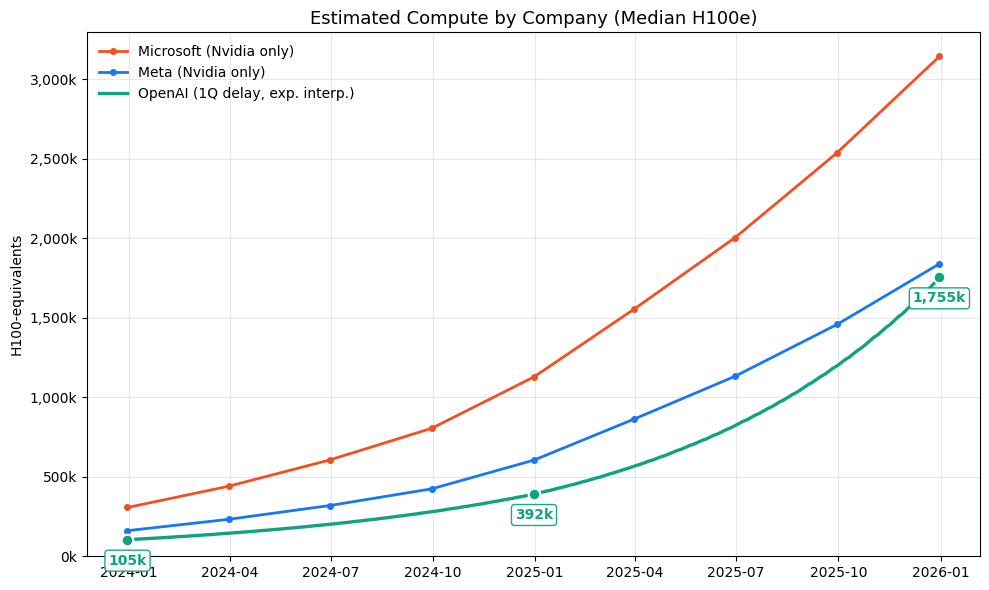

OpenAI piecewise exponential growth rates:
  2023-12-31 → 2024-12-31: +273.5%/yr
  2024-12-31 → 2025-12-31: +347.9%/yr

Year-end H100e totals:
            OpenAI (1Q delay)  Microsoft (Nvidia only)  Meta (Nvidia only)
2023-12-31             104524                   306912              161070
2024-12-31             391800                  1128599              605007
2025-12-31            1754848                  3144234             1839930


In [127]:
# ---------------------------------------------------------------------------
# Compare OpenAI (1-quarter-delay scenario) to Microsoft/Meta Nvidia-only totals
# Microsoft/Meta: every available quarter.
# OpenAI: smooth exponential fit through the 3 year-end estimates.
# ---------------------------------------------------------------------------
import numpy as np

openai_dates = pd.to_datetime(['2023-12-31', '2024-12-31', '2025-12-31'])

# OpenAI H100e from the 1-quarter-delay scenario (3 year-end anchor points)
openai_scenario = delay_scenario_results['1-quarter delay (3 months)']
openai_h100e = (
    openai_scenario.groupby('Lab Date')['Cumulative H100e'].sum()
    .reindex(openai_dates)
)

# Microsoft / Meta: quarterly cumulative H100e (all available end-of-quarter snapshots)
lab_totals = (
    chips_df.assign(**{'End date': pd.to_datetime(chips_df['End date'])})
    .query("Owner in ['Microsoft', 'Meta']")
    .groupby(['Owner', 'End date'])['Compute estimate in H100e (median)'].sum()
    .unstack('Owner')
    .sort_index()
)
# Start all series at end-of-2023 and drop the final (incomplete) quarter
lab_totals = lab_totals.loc[lab_totals.index >= pd.Timestamp('2023-12-31')].iloc[:-1]

# Piecewise exponential interpolation: fit each segment between consecutive
# OpenAI anchor points so the curve passes exactly through every dot.
def _exp_segment(d1, y1, d2, y2, n=100):
    t = np.array([(d - d1).days for d in pd.date_range(d1, d2, periods=n)], dtype=float)
    k = np.log(y2 / y1) / (d2 - d1).days
    dates = pd.date_range(d1, d2, periods=n)
    return dates, y1 * np.exp(k * t), k

y_vals = openai_h100e.values.astype(float)
seg_dates, seg_curves, seg_ks = [], [], []
for i in range(len(openai_dates) - 1):
    d, c, k = _exp_segment(openai_dates[i], y_vals[i],
                           openai_dates[i + 1], y_vals[i + 1])
    seg_dates.append(d); seg_curves.append(c); seg_ks.append(k)

LAB_COLORS = {
    'OpenAI (1Q delay)':       '#10a37f',
    'Microsoft (Nvidia only)': '#f25022',
    'Meta (Nvidia only)':      '#1877f2',
}

fig, ax = plt.subplots(figsize=(10, 6))

# Microsoft & Meta: connected quarterly points
for owner, display in [('Microsoft', 'Microsoft (Nvidia only)'),
                       ('Meta',      'Meta (Nvidia only)')]:
    s = lab_totals[owner].dropna()
    ax.plot(s.index, s.values, marker='o', markersize=4, linewidth=2.0,
            color=LAB_COLORS[display], label=display)

# OpenAI: piecewise exponential segments + the 3 anchor points
openai_color = LAB_COLORS['OpenAI (1Q delay)']
for i, (d, c) in enumerate(zip(seg_dates, seg_curves)):
    ax.plot(d, c, linewidth=2.4, color=openai_color,
            label='OpenAI (1Q delay, exp. interp.)' if i == 0 else None)
ax.scatter(openai_dates, y_vals, s=70, zorder=6,
           color=openai_color, edgecolor='white', linewidth=1.5)
for x, y in zip(openai_dates, y_vals):
    ax.annotate(f'{y/1000:,.0f}k',
                xy=(x, y), xytext=(0, -18), textcoords='offset points',
                fontsize=10, fontweight='bold', ha='center',
                color=openai_color,
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                          edgecolor=openai_color, linewidth=1.0, alpha=0.95))

ax.set_title('Estimated Compute by Company (Median H100e)', fontsize=13)
ax.set_ylabel('H100-equivalents')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:,.0f}k'))
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', frameon=False)
plt.tight_layout()
plt.show()

# Print year-end comparison table
comparison_table = pd.DataFrame({
    'OpenAI (1Q delay)':       openai_h100e,
    'Microsoft (Nvidia only)': lab_totals['Microsoft'].reindex(openai_dates),
    'Meta (Nvidia only)':      lab_totals['Meta'].reindex(openai_dates),
})
comparison_table.index = comparison_table.index.strftime('%Y-%m-%d')
seg_labels = [f"{openai_dates[i].strftime('%Y-%m-%d')} → "
              f"{openai_dates[i+1].strftime('%Y-%m-%d')}: "
              f"{np.exp(seg_ks[i]*365)-1:+.1%}/yr"
              for i in range(len(seg_ks))]
print('OpenAI piecewise exponential growth rates:')
for lbl in seg_labels:
    print('  ' + lbl)
print()
print('Year-end H100e totals:')
print(comparison_table.round(0).astype('Int64').to_string())


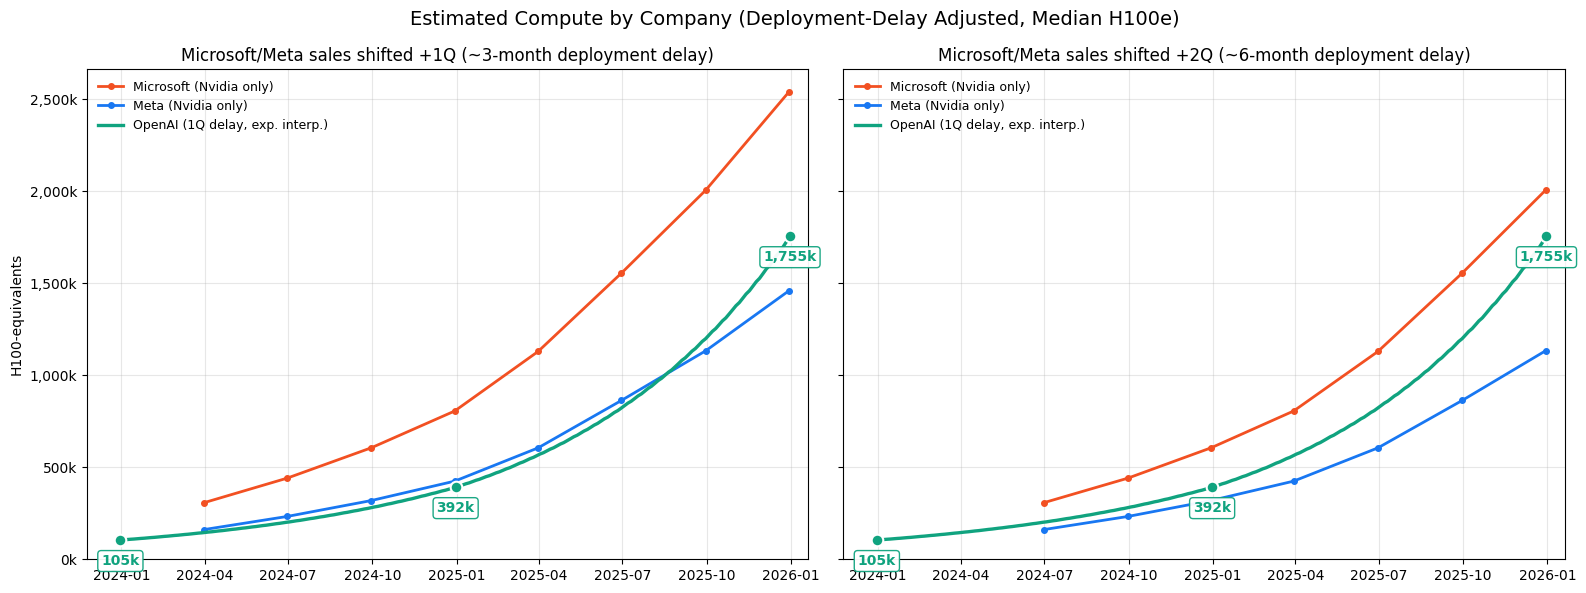

In [128]:
# ---------------------------------------------------------------------------
# Deployment-delay adjusted view: Microsoft/Meta sales shifted forward by
# 1 or 2 quarters to approximate when chips actually become operational.
# Shifted points landing after 2025-12-31 are dropped (those would represent
# future deployments projected from past sales, not observed fleets).
# ---------------------------------------------------------------------------
import numpy as np
from pandas.tseries.offsets import DateOffset

cap_date = pd.Timestamp('2025-12-31')

lab_totals_all = (
    chips_df.assign(**{'End date': pd.to_datetime(chips_df['End date'])})
    .query("Owner in ['Microsoft', 'Meta']")
    .groupby(['Owner', 'End date'])['Compute estimate in H100e (median)'].sum()
    .unstack('Owner')
    .sort_index()
    .loc[lambda d: d.index >= pd.Timestamp('2023-12-31')]
)

# OpenAI anchors + piecewise-exponential interpolation (shared by both panels).
openai_dates = pd.to_datetime(['2023-12-31', '2024-12-31', '2025-12-31'])
openai_scenario = delay_scenario_results['1-quarter delay (3 months)']
openai_h100e = (
    openai_scenario.groupby('Lab Date')['Cumulative H100e'].sum()
    .reindex(openai_dates)
)
y_vals = openai_h100e.values.astype(float)

def _exp_segment(d1, y1, d2, y2, n=100):
    dates = pd.date_range(d1, d2, periods=n)
    t = np.array([(d - d1).days for d in dates], dtype=float)
    k = np.log(y2 / y1) / (d2 - d1).days
    return dates, y1 * np.exp(k * t)

openai_segments = [
    _exp_segment(openai_dates[i], y_vals[i], openai_dates[i+1], y_vals[i+1])
    for i in range(len(openai_dates) - 1)
]

LAB_COLORS = {
    'Microsoft (Nvidia only)': '#f25022',
    'Meta (Nvidia only)':      '#1877f2',
    'OpenAI (1Q delay)':       '#10a37f',
}
OWNER_DISPLAY = {'Microsoft': 'Microsoft (Nvidia only)',
                 'Meta':      'Meta (Nvidia only)'}


def _plot_labs(ax, totals):
    for owner, display in OWNER_DISPLAY.items():
        s = totals[owner].dropna()
        s = s[s.index <= cap_date]
        ax.plot(s.index, s.values, marker='o', markersize=4, linewidth=2.0,
                color=LAB_COLORS[display], label=display)


def _plot_openai(ax):
    c = LAB_COLORS['OpenAI (1Q delay)']
    for i, (d, y) in enumerate(openai_segments):
        ax.plot(d, y, linewidth=2.4, color=c,
                label='OpenAI (1Q delay, exp. interp.)' if i == 0 else None)
    ax.scatter(openai_dates, y_vals, s=70, zorder=6,
               color=c, edgecolor='white', linewidth=1.5)
    for x, y in zip(openai_dates, y_vals):
        ax.annotate(f'{y/1000:,.0f}k',
                    xy=(x, y), xytext=(0, -18), textcoords='offset points',
                    fontsize=10, fontweight='bold', ha='center', color=c,
                    bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                              edgecolor=c, linewidth=1.0, alpha=0.95))


fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, q_shift in zip(axes, [1, 2]):
    shifted = lab_totals_all.copy()
    shifted.index = shifted.index + DateOffset(months=3 * q_shift)
    _plot_labs(ax, shifted)
    _plot_openai(ax)
    ax.set_title(f'Microsoft/Meta sales shifted +{q_shift}Q '
                 f'(~{3 * q_shift}-month deployment delay)', fontsize=12)
    ax.set_xlim(right=cap_date + pd.Timedelta(days=20))
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:,.0f}k'))
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', frameon=False, fontsize=9)

axes[0].set_ylabel('H100-equivalents')
fig.suptitle('Estimated Compute by Company (Deployment-Delay Adjusted, Median H100e)',
             fontsize=14)
plt.tight_layout()
plt.show()
